# Modeling BLS signal from a single magnetic layer using the reciprocity theorem #2

This example shows how SpinWaveToolkit (SWT) can be used to calculate the BLS signal using the reciprocity theorem and laser electric fields in reciprocal space.

The only difference to example #1 is the use of laser electric fields in reciprocal space (compared to electric fields in real space in example #1). The use of reciprocal-space fields results in potentially faster calculations of the final BLS spectra. They should produce the same results (when rescaled), but it is not guaranteed (especially when calculating coherent magnon signal, which is not the case in this example). Therefore, make sure to (briefly) compare results of the two approaches before coming to conclusions.

Source publication: Krčma et al., *Science Advances* **11**, eady8833 (2025). DOI: [10.1126/sciadv.ady8833](https://doi.org/10.1126/sciadv.ady8833)

### 1. Import modules and define parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SpinWaveToolkit as SWT

In [2]:
# Define parameters
Bext = 50e-3            # (T) external field
theta = np.pi / 2       # (rad) out-of-plane angle (fixed)
d_layer = 30e-9         # (m) magnetic layer thickness
material = SWT.NiFe     # Material
Nf_common = 101         # number of frequency points for Bloch function
fmin, fmax = 1e9, 35e9  # (Hz) frequency range for Bloch functions

NA = 0.75               # Numerical Aperture (NA) for the lens

# Define the Kx,Ky grid limits and resolution.
k_min = 1e-6            # (rad/m) minimum k (avoid zero if necessary)
k_max = 20e6            # (rad/m) maximum k (as in original kxi range)
dk = 0.2e6
Nk = int(round((k_max-k_min)/dk))  # resolution in Kx and Ky

### 2. Calculate the dynamic susceptibility

Now, the dynamic susceptibility of spin waves needs to be calculated. We do this by calculating the respective spin-wave Bloch functions and from those we construct the magneto-optical dynamic susceptibility tensor.

When building the dynamic magnetization components `mx`, `my`, `mz` from Bloch functions, the direction of static magnetization has to comply with the `phi0` and `theta` parameters (e.g. here $\vec{M}_0\parallel y$, so `my==0`). It is recommended to stick to magnetization directions parallel with the main coordinate axes, as calculation of the dynamic components is not so trivial in the general case. Similarly, it is easier to rotate the electric fields than to rotate the susceptibility tensor, and therefore the magneto-optical tensors are implemented only for magnetization direction parallel to x, y, or z.

In this simple case, we assume only linear part of the MO susceptibility tensor and therefore we use `SWT.bls.susceptibilities.mo_linear()` to construct it. However, SWT offers even quadratic MO calculations. See the documentation of the `susceptibilities` submodule for more details.

In [3]:
print("Preparing dynamic susceptibility tensor...")

# Setup k-space grid
kx_grid = np.linspace(-k_max, k_max, Nk)
ky_grid = np.linspace(-k_max, k_max, Nk)
KX, KY = np.meshgrid(kx_grid, ky_grid, indexing="ij")

# k-magnitude and propagation angle
phi0 = np.pi / 2
kxi = np.sqrt(KX**2 + KY**2)
phi = SWT.wrapAngle(np.arctan2(KY, KX) + phi0)
phi[kxi <= 1e-12] = 0.0  # avoid undefined angle at k=0

# Flatten for vectorized evaluation
kxi_fl = kxi.flatten()
phi_fl = phi.flatten()

# Allocate Bloch function storage
Bloch2D = np.zeros((Nf_common, Nk, Nk), dtype=complex)
w_common = np.linspace(2 * np.pi * fmin, 2 * np.pi * fmax, Nf_common)  # common frequency axis

# ...
# Create a SingleLayer model for the current kxi and phi.
# Note: We pass kxi and phi as flattened arrays of same shape.
model = SWT.SingleLayer(Bext=Bext, kxi=kxi_fl, theta=theta,
                        phi=phi_fl, d=d_layer, material=material)
# Compute the Bloch functions for n=0,1,2.
# The returned w has shape (Nf_common,) and bf has shape (Nf_common, len(kxi))
w0, bf0 = model.GetBlochFunction(n=0, Nf=Nf_common)
w1, bf1 = model.GetBlochFunction(n=1, Nf=Nf_common)
# reshape Bloch functions to match the Kx,Ky grid shape
bf0 = bf0.reshape((Nf_common, Nk, Nk))
bf1 = bf1.reshape((Nf_common, Nk, Nk))
# Loop over all grid points in the Kx,Ky plane.
for i in range(Nk):
    for j in range(Nk):
        # Interpolate the Bloch functions to the common frequency axis.
        bf0_interp = np.interp(w_common, w0, bf0[:, i, j], left=0, right=0)
        bf1_interp = np.interp(w_common, w1, bf1[:, i, j], left=0, right=0)

        # Sum Bloch functions for n=0,1,2
        Bloch2D[:, i, j] = bf0_interp + bf1_interp

# Build susceptibility tensor χ
mx = Bloch2D
my = np.zeros_like(Bloch2D)
mz = Bloch2D * -1j
chi = SWT.bls.susceptibilities.mo_linear([mx, my, mz])

Preparing dynamic susceptibility tensor...


### 3. Prepare the electric fields

Now, the electric fields need to be calculated. Ei corresponds to the driving field (incident laser) and the Ej to the virtual source. In accordance with our BLS detection scheme, they are calculated with orthogonal polarizations. [Note that this is the usual condition to maximize SW signal, but the model can calculate signal from an arbitrary polarization direction of the fields, allowing for polarization analysis studies, such as Szulc et al. [arXiv:2602.15760 (2026)](https://doi.org/10.48550/arXiv.2602.15760).] The electric fields can either be obtained from SWT or numerically (FDTD solvers).

To get the field from SWT, the `ObjectiveLens` class can be used. To rotate the polarization, you can use the `rotate_field()` helper function or set the polarization angle (if available by the respective method of `ObjectiveLens`).

In [4]:
print("Preparing focal field...")
objective = SWT.bls.ObjectiveLens(NA=NA, wavelength=532e-9, f0=10, f=1e-3)
Ei_fields = objective.getPupilField(z=0, KX=KX, KY=KY, polarization_type="linear",
                                    polarization_angle_deg=0)
Ej_fields = objective.getPupilField(z=0, KX=KX, KY=KY, polarization_type="linear",
                                    polarization_angle_deg=90)  # Field with rotated polarization

Preparing focal field...


### 4. Calculate the BLS signal

In [5]:
print("Calculating BLS signal...")
# Using the optimized einsum-based function
sigmaSW, qmEiEj = SWT.bls.get_signal_RT_pupil(
    KxKy=(kx_grid, ky_grid),  # common k-space grid for E fields and susceptibility
    Ei_fields=Ei_fields,
    Ej_fields=Ej_fields,
    Chi=chi,
    coherent_exc=False  # incoherent (thermal) SWs
)

Calculating BLS signal...


### 5. Visualize the results

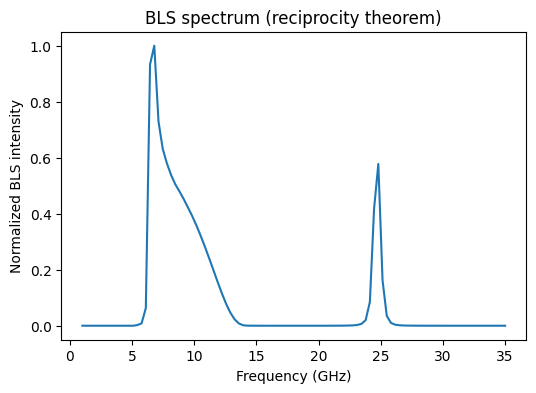

In [6]:
plt.figure(figsize=(6,4))
plt.plot(w_common/(np.pi*2e9), sigmaSW / np.max(sigmaSW))
plt.xlabel("Frequency (GHz)")
plt.ylabel("Normalized BLS intensity")
plt.title("BLS spectrum (reciprocity theorem)")
plt.show()

### (6. - optional) Visualize the dynamic susceptibility and the transfer function 

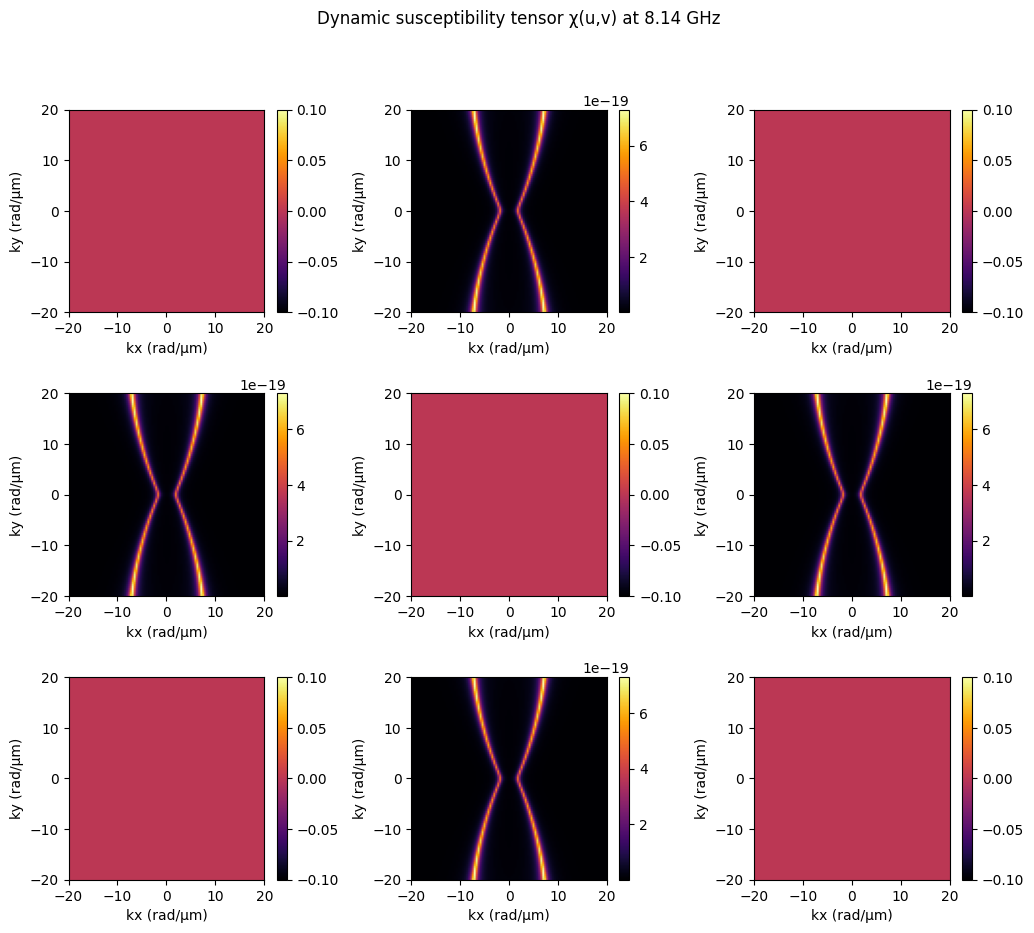

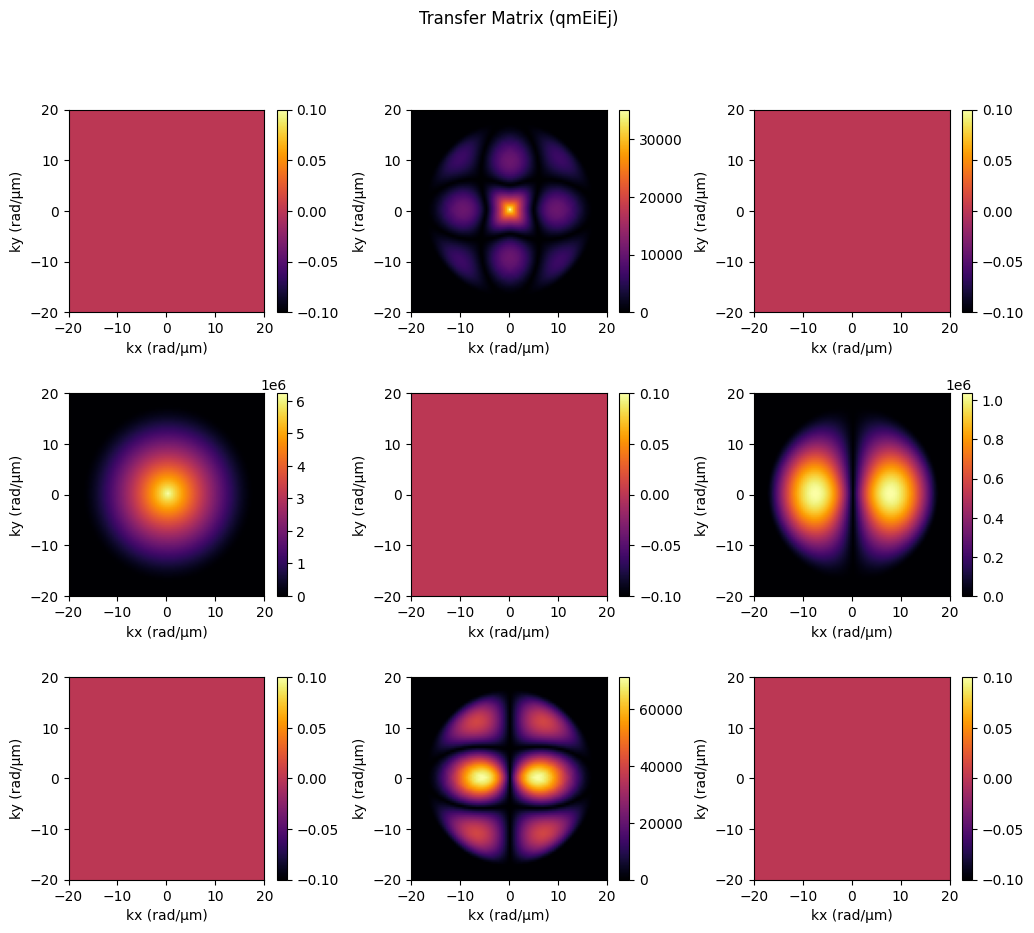

In [7]:
# Choose frequency to visualize
f_desired = 8 # GHz, change this to any frequency you want

# Find the closest index in w_common
f_idx = np.argmin(np.abs(w_common/(2*np.pi*1e9) - f_desired))
f_plot = w_common[f_idx] / (2*np.pi*1e9)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

for u in range(3):
    for v in range(3):
        ax = axes[u, v]
        im = ax.imshow(
            np.abs(chi[u, v, f_idx, :, :]).T,
            extent=(kx_grid[0]*1e-6, kx_grid[-1]*1e-6,
                    ky_grid[0]*1e-6, ky_grid[-1]*1e-6),
            origin='lower', aspect='auto', cmap='inferno'
        )
        fig.colorbar(im, ax=ax)
        ax.set_xlabel("kx (rad/µm)")
        ax.set_ylabel("ky (rad/µm)")

plt.suptitle(f"Dynamic susceptibility tensor χ(u,v) at {f_plot:.2f} GHz")
plt.show()

# Plot qmEiEj matrix
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

for u in range(3):
    for v in range(3):
        ax = axes[u, v]
        im = ax.imshow(
            np.abs(qmEiEj[u, v]).T,
            extent=(kx_grid[0]*1e-6, kx_grid[-1]*1e-6,
                    ky_grid[0]*1e-6, ky_grid[-1]*1e-6),
            origin='lower', aspect='auto', cmap='inferno'
        )
        fig.colorbar(im, ax=ax)
        ax.set_xlabel("kx (rad/µm)")
        ax.set_ylabel("ky (rad/µm)")

plt.suptitle("Transfer Matrix (qmEiEj)")
plt.show()